2.0.2


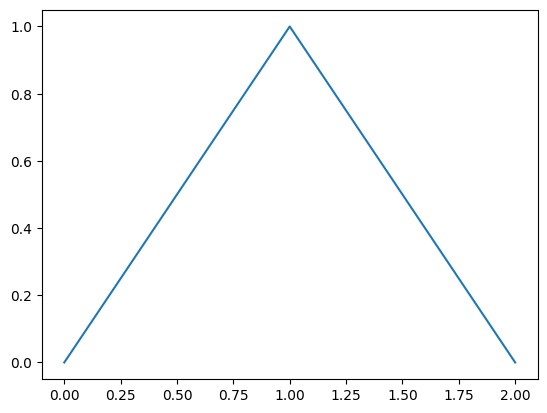

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print(np.__version__)
plt.plot([0, 1, 2], [0, 1, 0])
plt.show()

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


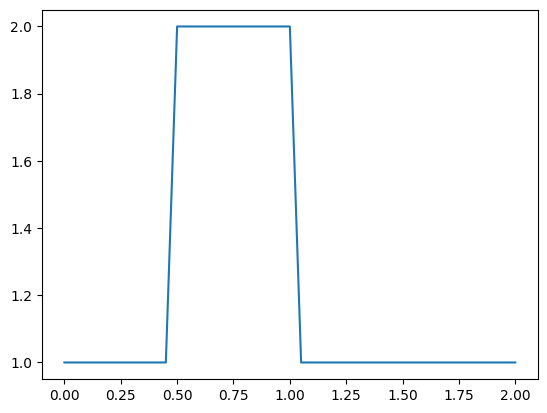

In [2]:
import numpy as np
import matplotlib.pyplot as plt

nx = 41
dx = 2 / (nx - 1)
nt = 25
dt = 0.025
c = 1

# x 좌표 배열: 0부터 2까지 41개 점
x = np.linspace(0, 2, nx)

# 초기 조건: 전부 1인데, 0.5 <= x <= 1 구간만 2
u = np.ones(nx)
u[int(0.5/dx):int(1/dx + 1)] = 2

print(u)
plt.plot(x, u)
plt.show()

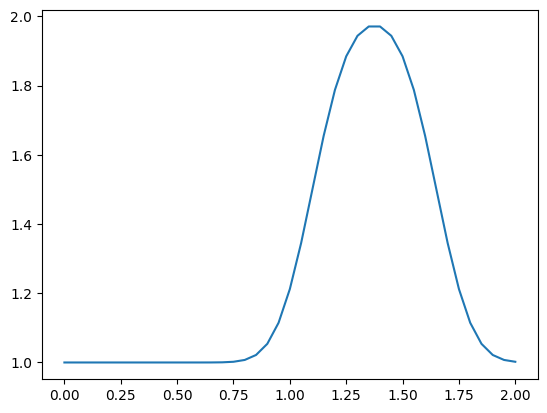

In [3]:
un = np.ones(nx)   # 이전 시각 값을 담을 임시 배열

for n in range(nt):
    un = u.copy()              # 현재 상태를 복사해서 보관
    for i in range(1, nx):     # i=0은 경계라 건드리지 않음
        u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])

plt.plot(x, u)
plt.show()

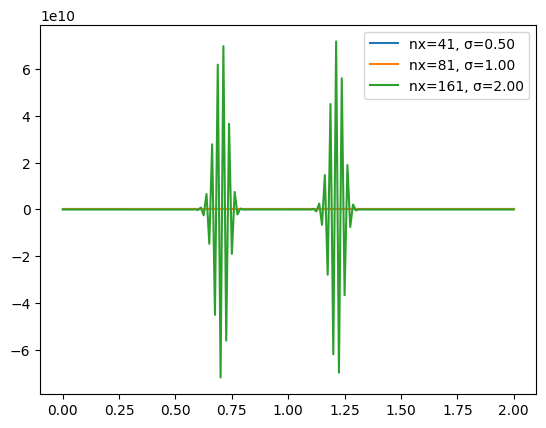

In [4]:
def linear_convection(nx, nt=25, dt=0.025, c=1):
    dx = 2 / (nx - 1)
    x = np.linspace(0, 2, nx)
    u = np.ones(nx)
    u[int(0.5/dx):int(1/dx + 1)] = 2
    
    for n in range(nt):
        un = u.copy()
        for i in range(1, nx):
            u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])
    
    sigma = c * dt / dx
    return x, u, sigma

for nx in [41, 81, 161]:
    x, u, sigma = linear_convection(nx)
    plt.plot(x, u, label=f'nx={nx}, σ={sigma:.2f}')

plt.legend()
plt.show()

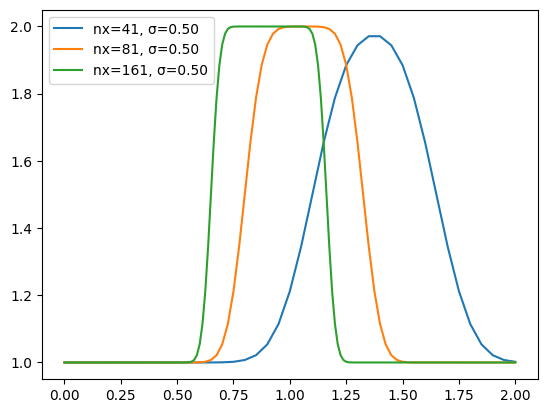

In [5]:
for nx in [41, 81, 161]:
    dx = 2 / (nx - 1)
    dt = 0.5 * dx / 1        # σ = 0.5 로 고정
    x, u, sigma = linear_convection(nx, nt=25, dt=dt)
    plt.plot(x, u, label=f'nx={nx}, σ={sigma:.2f}')

plt.legend()
plt.show()
